# Binary Classification with a Calibrated, Explainable Backbone Ensemble

The previous notebooks established that **transfer learning wins** on this ~4.4k-image
dataset: the from-scratch CNN (`04_gap`) and the hybrid CNN+transformer (`05_attention`)
trailed the ImageNet-pretrained **DenseNet-121** of `06_pretrained` (the CheXNet
architecture), which reached ~0.99 validation AUC and the best test accuracy.

This notebook tries to beat all of them *and* be honest about what a real-world
pneumonia screening tool would actually need. Raw AUC is not enough in a clinic, so we
add the four things a deployable model is expected to have:

| Concern | What a real tool needs | What we do here |
| --- | --- | --- |
| **Accuracy / robustness** | Squeeze the last few points; don't bet on one model | **Ensemble** two diverse pretrained backbones (DenseNet-121 + EfficientNetV2-B0) and average their probabilities, with **test-time augmentation** |
| **Don't miss disease** | A screen must catch nearly every true case | **Clinical operating point**: pick the threshold for a target *sensitivity* (recall ≥ 0.95), not F1 |
| **Trustworthy scores** | "0.8" should mean ~80% of such cases are positive | **Probability calibration** via temperature scaling + a reliability curve |
| **Auditability** | Show *where* the model looks; catch shortcut learning | **Grad-CAM** heatmaps on real test images |

Everything downstream of training (threshold, calibration) is fit on the **validation**
set and only *reported* on the held-out **test** set, so the test numbers stay honest.

> **Compute note.** Two pretrained backbones fine-tuned on CPU is heavy — expect this to
> run noticeably longer than `06` (which took ~8.8h). Drop `head_epochs`/`finetune_epochs`
> or comment out one backbone in `BACKBONES` to iterate faster.

## Setup

In [1]:
# --- remote/local setup: all logic lives in visualization.colab_bootstrap ---
import os
import sys

try:
    from visualization import colab_bootstrap
except ModuleNotFoundError:
    if "google.colab" in sys.modules and not os.path.exists("ConvolutedComputerVision"):
        !git clone -q https://github.com/samlowe106/ConvolutedComputerVision.git
    for _p in (
        "../src",
        "ConvolutedComputerVision/src",
        "/content/ConvolutedComputerVision/src",
    ):
        if os.path.exists(_p):
            sys.path.insert(0, os.path.abspath(_p))
            break
    from visualization import colab_bootstrap

DATA_ROOT, CKPT_ROOT = colab_bootstrap(
    data_subdir="chest-x-ray-pneumonia",
    dataset_script="chest-x-ray-images-pneumonia/download_data.py",
)

Mounted at /content/drive
[colab_bootstrap] Colab run -> data='/content/drive/MyDrive/datasets/chest-x-ray-pneumonia', ckpt='/content/drive/MyDrive/cv-checkpoints'
[colab_bootstrap] 1 GPU(s) visible


In [2]:
import datetime

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from scipy.optimize import minimize_scalar
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, roc_auc_score

notebook_start_time = datetime.datetime.now()

In [3]:
test_dir = f"{DATA_ROOT}/test"
train_dir = f"{DATA_ROOT}/train"
validation_dir = f"{DATA_ROOT}/val"

# Both backbones are ImageNet-pretrained and expect 224x224 RGB; the grayscale X-rays
# load as three equal channels. Each backbone applies its OWN preprocessing inside the
# model (see build_transfer_model), so the datasets stay shared and yield raw [0, 255].
height, width, channels = 224, 224, 3

batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="rgb",
)

# validation/test are shuffle=False so labels stay aligned with model.predict and so the
# (order-preserving) test-time augmentation passes can be averaged element-wise.
validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="rgb",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="rgb",
    shuffle=False,
)

# cache the deterministic labels once -- reused everywhere below
y_val = np.concatenate([y for _, y in validation_ds], axis=0)
y_test = np.concatenate([y for _, y in test_ds], axis=0)

Found 4461 files belonging to 2 classes.
Found 771 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [4]:
from visualization import reset_keras, show_confusion_matrix, summary_graphics


def get_class_training_weights(train_ds, normalize=True):
    labels, counts = np.unique(
        np.concatenate([y for x, y in train_ds], axis=0), return_counts=True
    )
    total = sum(counts)

    weights = [total / (2 * count) for count in counts]
    max_weight = np.max(weights)

    if normalize:
        return {label: weights[i] / max_weight for i, label in enumerate(labels)}

    return {label: weights[i] for i, label in enumerate(labels)}

In [5]:
class_weight = get_class_training_weights(train_ds=train_ds)

print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

Weight for normal class: 1.000
Weight for pneumonia class: 0.346


## The ensemble members

We train two **different** pretrained backbones so their errors are at least partly
uncorrelated -- the whole point of an ensemble. Averaging correlated models buys little;
averaging diverse ones smooths out each one's idiosyncratic mistakes.

- **DenseNet-121** -- the CheXNet architecture, dense connectivity, ~8M params. The
  strongest single model in `06`.
- **EfficientNetV2-B0** -- a newer, compound-scaled backbone with a very different
  block design (fused-MBConv), ~7M params.

Both use the same recipe and the same head, built by `build_transfer_model`:

1. **Phase 1 -- frozen backbone.** Train only a fresh head so it adapts to the
   pretrained features without disturbing them.
2. **Phase 2 -- fine-tune the top.** Unfreeze the upper backbone layers at a low LR.
   We keep `BatchNormalization` layers frozen (standard fine-tuning practice -- their
   ImageNet running statistics are better than what 4.4k images would re-estimate) and
   leave the lower layers frozen too, which protects generic edge/texture filters and
   saves compute.

In [6]:
metrics = [
    tf.keras.metrics.TruePositives(name="tp"),
    tf.keras.metrics.TrueNegatives(name="tn"),
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
    tf.keras.metrics.AUC(name="auc"),
]


def make_callbacks(filepath):
    # select on val AUC (threshold-free, robust to the class imbalance)
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=filepath, save_best_only=True, monitor="val_auc", mode="max"
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=4, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5, patience=2
        ),
    ]


# kept modest because two backbones train on CPU; early stopping ends them sooner
head_epochs = 8
finetune_epochs = 8

# (label, backbone class, matching preprocess_input). Comment a line out to drop a member.
BACKBONES = [
    (
        "densenet",
        tf.keras.applications.DenseNet121,
        tf.keras.applications.densenet.preprocess_input,
    ),
    (
        "effnet",
        tf.keras.applications.EfficientNetV2B0,
        tf.keras.applications.efficientnet_v2.preprocess_input,
    ),
]

In [7]:
def build_transfer_model(backbone_cls, preprocess_input, name):
    base_model = backbone_cls(
        include_top=False, weights="imagenet", input_shape=(height, width, channels)
    )
    base_model.trainable = False  # phase 1: frozen feature extractor

    inputs = tf.keras.Input((height, width, channels), name="input")
    # light augmentation (no horizontal flip -- anatomically wrong for chest X-rays)
    x = tf.keras.layers.RandomRotation(0.1)(inputs)
    x = tf.keras.layers.RandomTranslation(0.1, 0.1)(x)
    x = preprocess_input(x)  # each backbone's expected input normalization
    x = base_model(x, training=False)  # keep BatchNorm in inference mode
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
    model = tf.keras.Model(inputs, outputs, name=name)
    return model, base_model


def unfreeze_top(base_model, fraction=0.4):
    # make the top `fraction` of conv layers trainable; keep BN layers frozen
    base_model.trainable = True
    cutoff = int(len(base_model.layers) * (1 - fraction))
    for i, layer in enumerate(base_model.layers):
        if i < cutoff or isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False


def train_member(label, backbone_cls, preprocess_input):
    # two-phase transfer learning; returns the path of the best saved model
    reset_keras()
    print(f"\n========== training member: {label} ==========")
    model, base_model = build_transfer_model(backbone_cls, preprocess_input, label)

    # phase 1: train the head on the frozen backbone
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=metrics,
    )
    print(f"[{label}] phase 1: training head on frozen backbone")
    history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=head_epochs,
        class_weight=class_weight,
        verbose=1,
        callbacks=make_callbacks(os.path.join(CKPT_ROOT, f"best_{label}_head.keras")),
    )
    summary_graphics(history, model, test_ds)

    # phase 2: fine-tune the top of the backbone at a low LR
    unfreeze_top(base_model, fraction=0.4)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=metrics,
    )
    print(f"[{label}] phase 2: fine-tuning top of backbone")
    ckpt_path = os.path.join(CKPT_ROOT, f"best_{label}.keras")
    history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=finetune_epochs,
        class_weight=class_weight,
        verbose=1,
        callbacks=make_callbacks(ckpt_path),
    )
    best = tf.keras.models.load_model(ckpt_path)
    summary_graphics(history, best, test_ds)
    return ckpt_path

## Train each member


========== training member: densenet ==========
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
[densenet] phase 1: training head on frozen backbone
Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 77s 398ms/step - accuracy: 0.8276 - auc: 0.9109 - loss: 0.1965 - precision: 0.9384 - recall: 0.8220 - tn: 967.0000 - tp: 2725.0000 - val_accuracy: 0.9442 - val_auc: 0.9842 - val_loss: 0.1439 - val_precision: 0.9565 - val_recall: 0.9683 - val_tn: 178.0000 - val_tp: 550.0000 - learning_rate: 0.0010
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 392ms/step - accuracy: 0.8832 - auc: 0.9548 - loss: 0.1399 - precision: 0.9556 - recall: 0.8839 - tn: 1010.0000 - tp: 2930.0000 - val_accuracy: 0.9339 - val_auc: 0.9879 - val_loss: 0.1579 - val_precision: 0.9726 - val_recall: 0.9366 - val_tn: 188.0000 - val_tp: 532.0000 - learning_rate: 0.0010
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 54s 387ms/step - accuracy: 0.8973 - auc: 0.9618 - loss: 0.1278 - precision: 0.9633 - recall: 0.8959 - tn: 1033.0000 - tp: 2970.0000 -

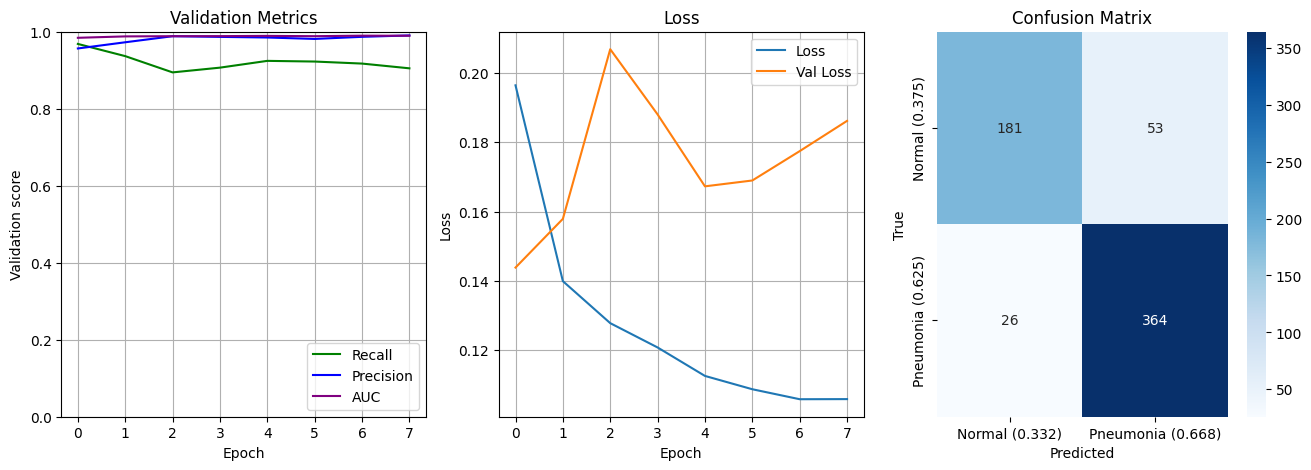

[densenet] phase 2: fine-tuning top of backbone
Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 84s 432ms/step - accuracy: 0.9237 - auc: 0.9796 - loss: 0.0954 - precision: 0.9775 - recall: 0.9184 - tn: 1267.0000 - tp: 3566.0000 - val_accuracy: 0.9403 - val_auc: 0.9924 - val_loss: 0.1498 - val_precision: 0.9888 - val_recall: 0.9296 - val_tn: 197.0000 - val_tp: 528.0000 - learning_rate: 1.0000e-05
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 77s 404ms/step - accuracy: 0.9413 - auc: 0.9847 - loss: 0.0785 - precision: 0.9823 - recall: 0.9379 - tn: 1090.0000 - tp: 3109.0000 - val_accuracy: 0.9416 - val_auc: 0.9940 - val_loss: 0.1464 - val_precision: 0.9925 - val_recall: 0.9278 - val_tn: 199.0000 - val_tp: 527.0000 - learning_rate: 1.0000e-05
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 58s 412ms/step - accuracy: 0.9516 - auc: 0.9899 - loss: 0.0626 - precision: 0.9862 - recall: 0.9481 - tn: 1102.0000 - tp: 3143.0000 - val_accuracy: 0.9520 - val_auc: 0.9950 - val_loss: 0.1160 - val_precision: 0.9908 - val_recall:

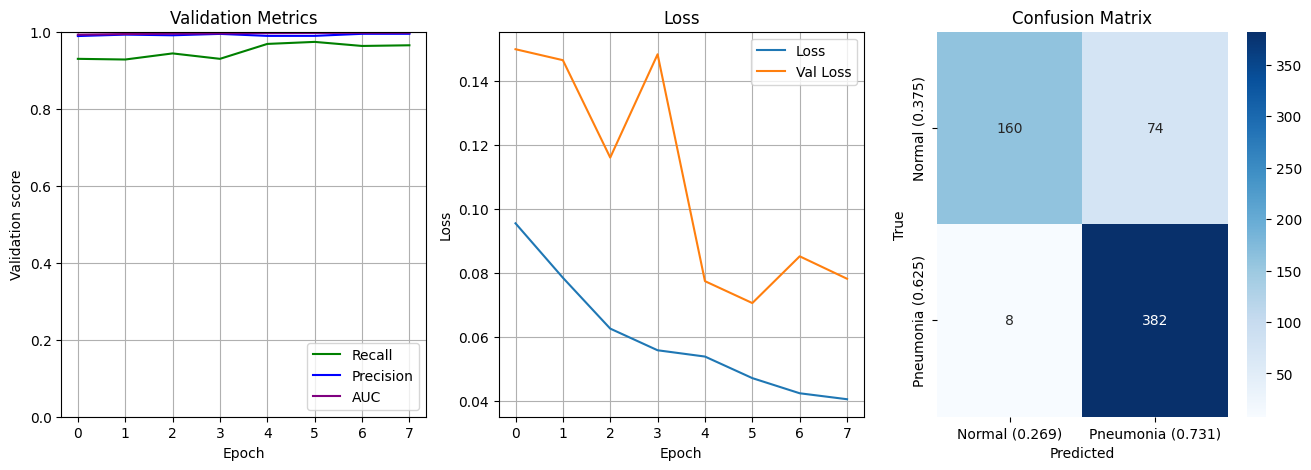


========== training member: effnet ==========
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
[effnet] phase 1: training head on frozen backbone
Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 409ms/step - accuracy: 0.8867 - auc: 0.9613 - loss: 0.1442 - precision: 0.9636 - recall: 0.8805 - tn: 1220.0000 - tp: 3419.0000 - val_accuracy: 0.9442 - val_auc: 0.9849 - val_loss: 0.1402 - val_precision: 0.9565 - val_recall: 0.9683 - val_tn: 178.0000 - val_tp: 550.0000 - learning_rate: 0.0010
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 49s 347ms/step - accuracy: 0.9110 - auc: 0.9734 - loss: 0.1055 - precision: 0.9728 - recall: 0.9056 - tn: 1062.0000 - tp: 3002.0000 - val_accuracy: 0.9429 - val_auc: 0.9866 - val_loss: 0.1435 - val_precision: 0.9781 - val_recall: 0.9437 - val_tn: 191.0000 - val_tp: 536.0000 - learning_rate: 0.0010
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 48s 342ms/step - accuracy: 0.9204 - auc: 0.9762 - loss: 0.0993 - precision: 0.9762 - recall: 0.9152 - tn: 1072.0000 - tp: 3034.0000 - va

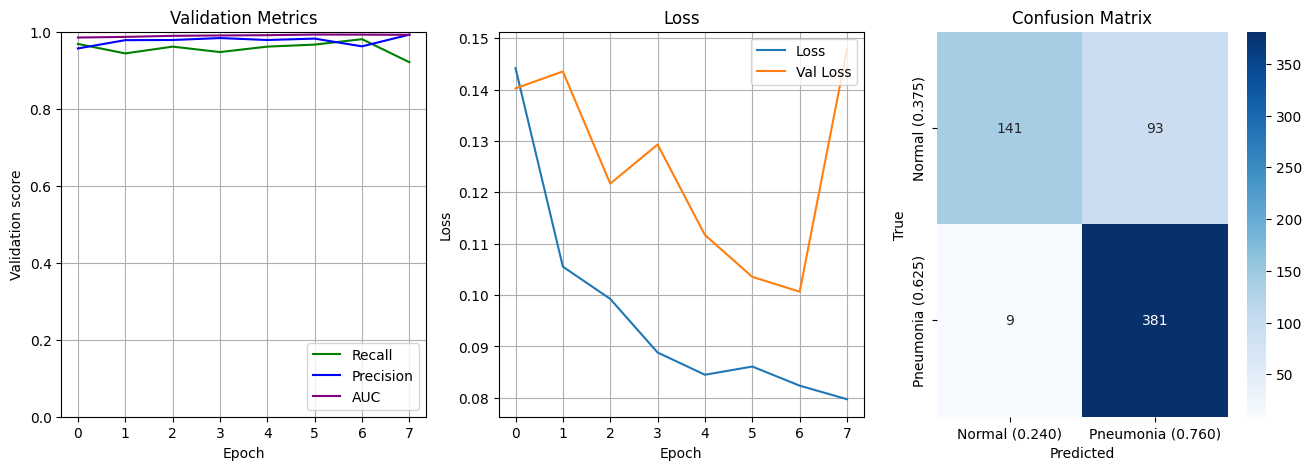

[effnet] phase 2: fine-tuning top of backbone
Epoch 1/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 76s 409ms/step - accuracy: 0.9356 - auc: 0.9866 - loss: 0.0763 - precision: 0.9821 - recall: 0.9302 - tn: 1283.0000 - tp: 3612.0000 - val_accuracy: 0.9546 - val_auc: 0.9931 - val_loss: 0.1112 - val_precision: 0.9872 - val_recall: 0.9507 - val_tn: 196.0000 - val_tp: 540.0000 - learning_rate: 1.0000e-05
Epoch 2/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 54s 388ms/step - accuracy: 0.9451 - auc: 0.9888 - loss: 0.0684 - precision: 0.9861 - recall: 0.9394 - tn: 1102.0000 - tp: 3114.0000 - val_accuracy: 0.9624 - val_auc: 0.9944 - val_loss: 0.1016 - val_precision: 0.9909 - val_recall: 0.9577 - val_tn: 198.0000 - val_tp: 544.0000 - learning_rate: 1.0000e-05
Epoch 3/8
140/140 ━━━━━━━━━━━━━━━━━━━━ 51s 362ms/step - accuracy: 0.9435 - auc: 0.9893 - loss: 0.0668 - precision: 0.9833 - recall: 0.9400 - tn: 1093.0000 - tp: 3116.0000 - val_accuracy: 0.9689 - val_auc: 0.9949 - val_loss: 0.0907 - val_precision: 0.9892 - val_recall: 0

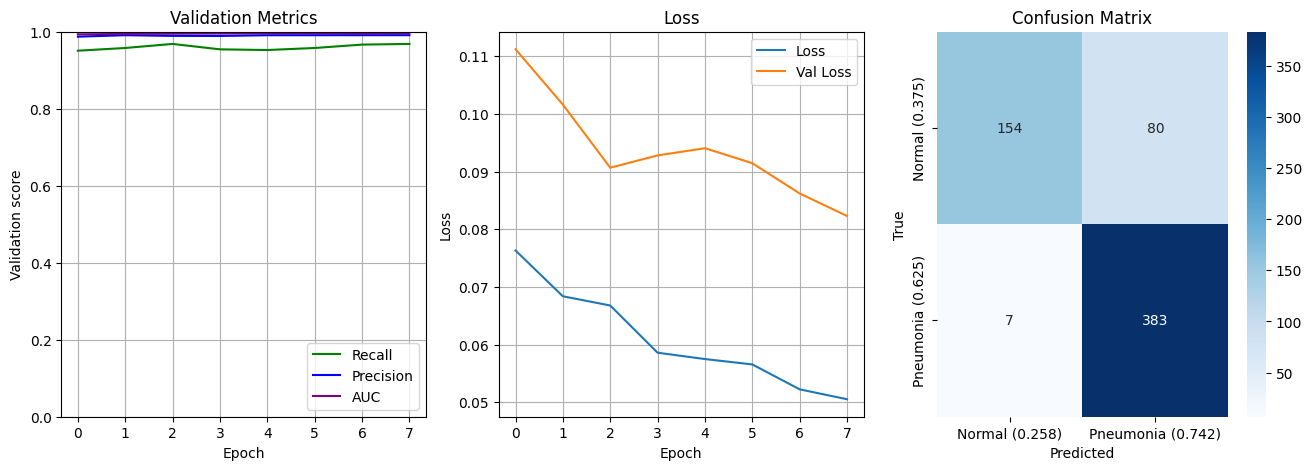


saved members: ['/content/drive/MyDrive/cv-checkpoints/best_densenet.keras', '/content/drive/MyDrive/cv-checkpoints/best_effnet.keras']


In [8]:
member_paths = []
for label, backbone_cls, preprocess_input in BACKBONES:
    member_paths.append(train_member(label, backbone_cls, preprocess_input))
print("\nsaved members:", member_paths)

## Ensemble + test-time augmentation (TTA)

Two robustness tricks, stacked:

- **Ensemble** -- average the sigmoid probabilities of the members. Because the backbones
  are architecturally different, their mistakes don't fully overlap, so the mean is
  steadier than either alone.
- **TTA** -- at inference, also predict on a few mildly augmented copies (small rotation,
  shift, zoom) of each image and average. This is the inference-time mirror of training
  augmentation: it reduces variance from the model latching onto a particular framing.

Because the val/test loaders are `shuffle=False`, every pass returns predictions in the
same order, so we can average them element-wise.

In [9]:
# mild, label-preserving augmentation for TTA (no flip -- anatomy is left/right specific)
tta_aug = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomTranslation(0.05, 0.05),
        tf.keras.layers.RandomZoom(0.05),
    ],
    name="tta_aug",
)


def predict_proba_tta(model, ds, n_aug=4):
    # average a clean pass with n_aug augmented passes (order preserved)
    passes = [model.predict(ds, verbose=0).ravel()]
    for _ in range(n_aug):
        aug_ds = ds.map(lambda x, y: (tta_aug(x, training=True), y))
        passes.append(model.predict(aug_ds, verbose=0).ravel())
    return np.mean(passes, axis=0)


def ensemble_proba(paths, ds, n_aug=4):
    # mean TTA probability across all ensemble members
    member_probs = []
    for p in paths:
        reset_keras()
        model = tf.keras.models.load_model(p)
        member_probs.append(predict_proba_tta(model, ds, n_aug=n_aug))
    return np.mean(member_probs, axis=0), member_probs


val_proba, val_member_probs = ensemble_proba(member_paths, validation_ds)
test_proba, test_member_probs = ensemble_proba(member_paths, test_ds)

print("Per-member vs ensemble ROC-AUC (test):")
for path, probs in zip(member_paths, test_member_probs):
    print(f"  {path:<22} {roc_auc_score(y_test, probs):.4f}")
print(f"  {'ENSEMBLE + TTA':<22} {roc_auc_score(y_test, test_proba):.4f}")

Per-member vs ensemble ROC-AUC (test):
  /content/drive/MyDrive/cv-checkpoints/best_densenet.keras 0.9669
  /content/drive/MyDrive/cv-checkpoints/best_effnet.keras 0.9666
  ENSEMBLE + TTA         0.9683


## Probability calibration (temperature scaling)

A model can rank cases well (high AUC) yet output over-confident probabilities. For
decision support the number itself has to be trustworthy: among cases scored ~0.8, about
80% should truly be pneumonia. **Temperature scaling** fits a single scalar `T` that
divides the logits, fit by minimizing validation cross-entropy. It cannot change the
ranking (so AUC is unchanged) -- it only rescales confidence. We then show a reliability
curve before vs after.

Fitted temperature: 0.601  (T>1 => model was over-confident)


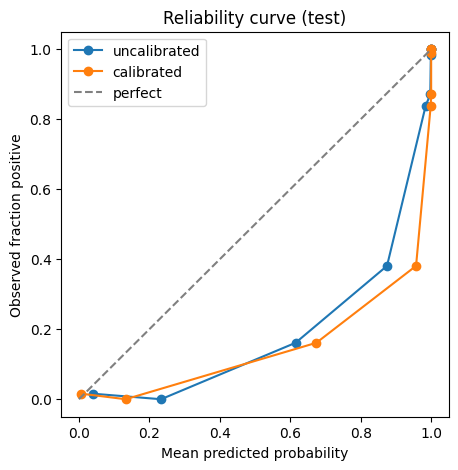

In [10]:
def _to_logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


# fit temperature on the VALIDATION ensemble probabilities
val_logits = _to_logit(val_proba)


def _nll(T):
    p = 1.0 / (1.0 + np.exp(-val_logits / T))
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return -np.mean(y_val * np.log(p) + (1 - y_val) * np.log(1 - p))


temperature = float(minimize_scalar(_nll, bounds=(0.05, 10.0), method="bounded").x)
print(f"Fitted temperature: {temperature:.3f}  (T>1 => model was over-confident)")


def calibrate(p):
    return 1.0 / (1.0 + np.exp(-_to_logit(p) / temperature))


test_proba_cal = calibrate(test_proba)

fig, ax = plt.subplots(figsize=(5, 5))
for probs, name in [(test_proba, "uncalibrated"), (test_proba_cal, "calibrated")]:
    frac_pos, mean_pred = calibration_curve(
        y_test, probs, n_bins=10, strategy="quantile"
    )
    ax.plot(mean_pred, frac_pos, marker="o", label=name)
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction positive")
ax.set_title("Reliability curve (test)")
ax.legend(loc="upper left")
plt.show()

## Clinical operating point

A pneumonia *screen* is judged mostly by **sensitivity (recall)** -- a missed case (false
negative) is far costlier than a false alarm a radiologist can rule out. So instead of the
F1-optimal threshold used in earlier notebooks, we pick the **highest threshold that still
achieves a target sensitivity** on the validation set (default 0.95), which maximizes
specificity subject to "almost never miss pneumonia." The threshold is chosen on
validation and only *applied* to test.

Clinical threshold: 0.869  (target sensitivity >= 0.95)

Test-set performance (ensemble + TTA, calibrated probabilities):
default 0.5                acc=0.832  sensitivity=0.990  specificity=0.568  precision=0.793  false negatives=4
clinical 0.869             acc=0.885  sensitivity=0.972  specificity=0.739  precision=0.861  false negatives=11

Test ROC-AUC: 0.9685


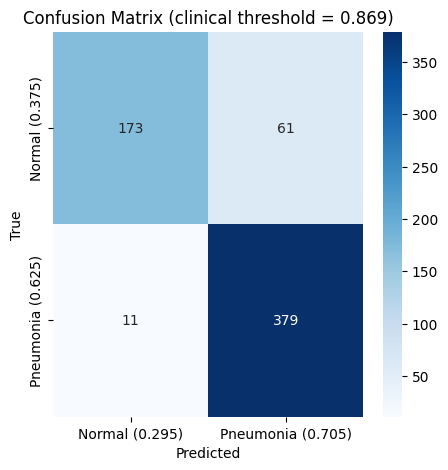

In [11]:
TARGET_SENSITIVITY = 0.95

# choose the threshold on calibrated VALIDATION probabilities
val_proba_cal = calibrate(val_proba)
prec, rec, thr = precision_recall_curve(y_val, val_proba_cal)
# precision_recall_curve returns len(thr)+1 points; align and keep those meeting recall
ok = rec[:-1] >= TARGET_SENSITIVITY
if ok.any():
    # among thresholds meeting the sensitivity target, take the largest (best specificity)
    clinical_threshold = float(thr[ok].max())
else:
    clinical_threshold = float(thr[np.argmax(rec[:-1])])
    print("WARNING: target sensitivity unreachable on val; using max-recall threshold")
print(
    f"Clinical threshold: {clinical_threshold:.3f}  (target sensitivity >= {TARGET_SENSITIVITY})\n"
)


def report(name, proba, thr_):
    pred = (proba >= thr_).astype("int32")
    tp = int(((pred == 1) & (y_test == 1)).sum())
    tn = int(((pred == 0) & (y_test == 0)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    prec_ = tp / (tp + fp) if (tp + fp) else float("nan")
    acc = (tp + tn) / len(y_test)
    print(
        f"{name:<26} acc={acc:.3f}  sensitivity={sens:.3f}  specificity={spec:.3f}  "
        f"precision={prec_:.3f}  false negatives={fn}"
    )


print("Test-set performance (ensemble + TTA, calibrated probabilities):")
report("default 0.5", test_proba_cal, 0.5)
report(f"clinical {clinical_threshold:.3f}", test_proba_cal, clinical_threshold)
print(f"\nTest ROC-AUC: {roc_auc_score(y_test, test_proba_cal):.4f}")

show_confusion_matrix(
    y_test,
    (test_proba_cal >= clinical_threshold).astype("int32"),
    title=f"Confusion Matrix (clinical threshold = {clinical_threshold:.3f})",
)

## How 07 compares

For reference, the test-set numbers recorded in the earlier notebooks:

| Notebook | Approach | Test acc @0.5 | Recall | False neg |
| --- | --- | --- | --- | --- |
| `04_gap` | CNN from scratch | 0.609 | 0.377 | 243 |
| `05_attention` | CNN + transformer | 0.840 | 0.956 | 17 |
| `06_pretrained` | DenseNet-121 (single) | 0.902 | 0.962 | 15 |
| **`07` (this)** | **DenseNet-121 + EfficientNetV2-B0 ensemble, TTA, calibrated** | _see above_ | | |

The headline isn't just accuracy: 07 reports a **calibrated** probability, a threshold
chosen for a **clinical sensitivity target**, and the explanations below -- the package a
real screening aid would ship with.

## Grad-CAM: where is the model looking?

Accuracy alone can't tell you *why* a model is right -- chest-X-ray nets are notorious for
shortcut learning (latching onto burned-in text, chest tubes, or scanner artifacts instead
of lung opacity). **Grad-CAM** weights the last convolutional feature map by the gradient
of the pneumonia score, producing a heatmap of the regions that drove the prediction. A
trustworthy model should highlight lung fields, not the image border or markers.

We compute it on the **DenseNet-121** member (its final `relu` feature map is the standard
CheXNet Grad-CAM target). The head layers after the backbone are reused to keep the
gradient path faithful to the trained model.

In [12]:
def make_gradcam_components(model_path, preprocess_input):
    model = tf.keras.models.load_model(model_path)
    # the backbone is the nested functional sub-model (keeps its own name, e.g.
    # "densenet121"), so find it by type rather than by our member label
    base = next(layer for layer in model.layers if isinstance(layer, tf.keras.Model))

    # feature extractor: image -> last conv feature map (DenseNet's final "relu")
    feature_model = tf.keras.Model(base.input, base.output)

    # classifier head: feature map -> pneumonia probability, reusing the trained layers
    head_input = tf.keras.Input(base.output.shape[1:])
    x = head_input
    started = False
    for layer in model.layers:
        if layer is base:
            started = True
            continue
        if started:
            x = layer(x)
    head_model = tf.keras.Model(head_input, x)
    return feature_model, head_model, preprocess_input


def gradcam_heatmap(img_batch, feature_model, head_model, preprocess_input):
    x = preprocess_input(tf.cast(img_batch, tf.float32))
    with tf.GradientTape() as tape:
        conv = feature_model(x)
        tape.watch(conv)
        score = head_model(conv)[:, 0]
    grads = tape.gradient(score, conv)
    weights = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)  # GAP over spatial dims
    cam = tf.reduce_sum(weights * conv, axis=-1)  # weighted feature-map sum
    cam = tf.nn.relu(cam)
    cam = cam / (tf.reduce_max(cam, axis=(1, 2), keepdims=True) + 1e-8)
    return cam.numpy(), score.numpy()


# DenseNet is member 0; only build Grad-CAM if it's in the ensemble
dn_label, dn_cls, dn_pre = BACKBONES[0]
feature_model, head_model, dn_pre = make_gradcam_components(
    os.path.join(CKPT_ROOT, f"best_{dn_label}.keras"), dn_pre
)

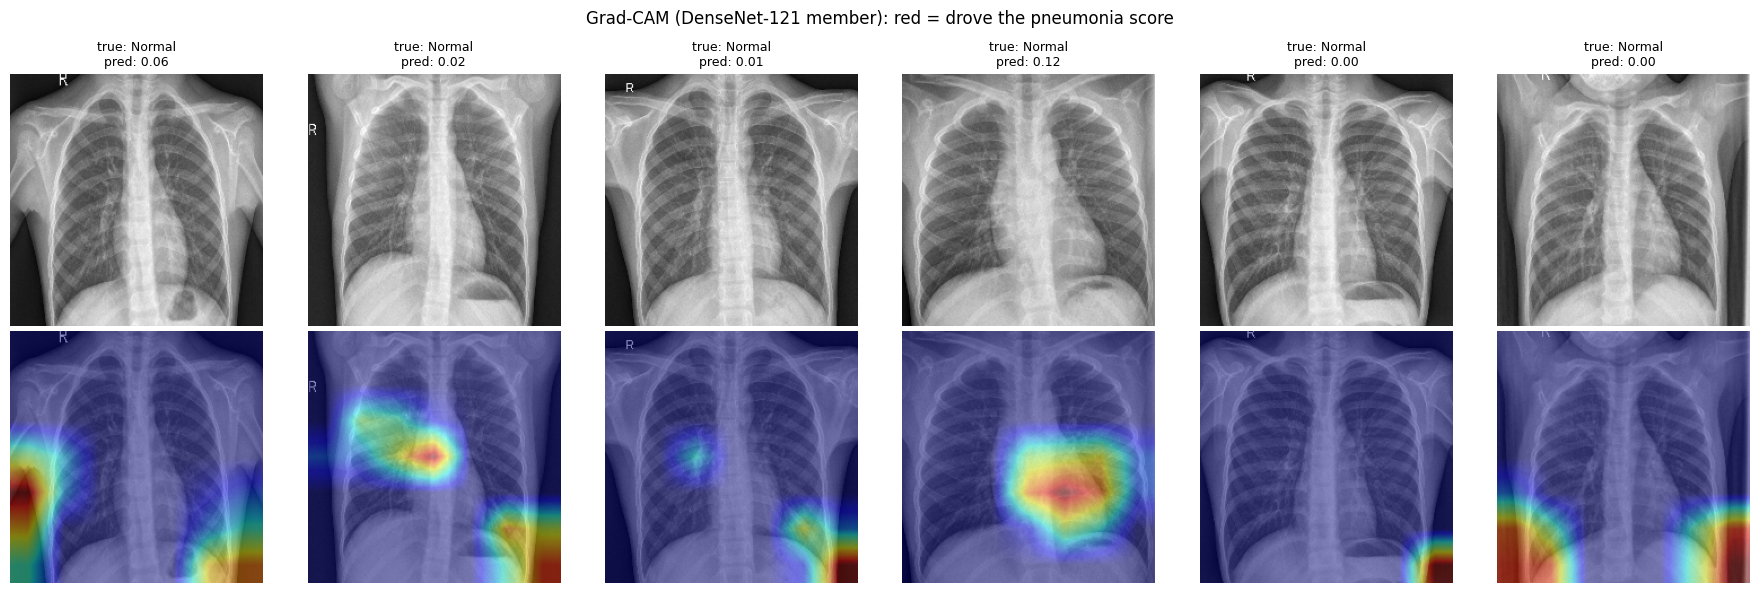

In [13]:
# grab a batch of test images and overlay Grad-CAM on a few of them
images, labels = next(iter(test_ds))
cams, scores = gradcam_heatmap(images, feature_model, head_model, dn_pre)

class_names = ("Normal", "Pneumonia")
n_show = 6
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    img = images[i].numpy().astype("uint8")
    cam = tf.image.resize(cams[i][..., None], (height, width)).numpy()[..., 0]

    axes[0, i].imshow(img)
    axes[0, i].set_title(
        f"true: {class_names[int(labels[i])]}\npred: {scores[i]:.2f}", fontsize=9
    )
    axes[0, i].axis("off")

    axes[1, i].imshow(img)
    axes[1, i].imshow(cam, cmap="jet", alpha=0.45)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("input", fontsize=10)
axes[1, 0].set_ylabel("Grad-CAM", fontsize=10)
fig.suptitle("Grad-CAM (DenseNet-121 member): red = drove the pneumonia score")
plt.tight_layout()
plt.show()

In [14]:
notebook_end_time = datetime.datetime.now()
print(
    f"Notebook last run (end-to-end): {notebook_end_time} "
    f"(duration: {notebook_end_time - notebook_start_time})"
)

Notebook last run (end-to-end): 2026-07-10 08:27:24.303941 (duration: 1:11:45.013881)
